
# Toy Application of the Library: Estimating the Expected Loss of a Regression Model

In this example, we use some of the tools provided by the library to solve a simple but meaningful practical problem: estimating the expected value of a loss function in a regression model.

The goal is to show how an expectation involving Gaussian random variables can be transformed into an integral over the unit cube $[0,1]^4$, which is exactly the type of domain handled by our sampling methods.

## Problem setting

We consider a linear regression model of the form

$$
y_{\text{model}}(X)
=
\theta_0+\theta_1X_1+\theta_2X_2+\theta_3X_3,
$$

where

$$
X=(X_1,X_2,X_3)\sim \mathcal N(0,I_3).
$$

This means that $X_1$, $X_2$, and $X_3$ are independent standard normal random variables.

The true function is defined by

$$
y_{\text{true}}(X)
=
\sin(X_1)+\frac12 X_2^2-0.3X_3.
$$

We observe a noisy version of this true output:

$$
Y = y_{\text{true}}(X)+\varepsilon,
$$

where

$$
\varepsilon\sim \mathcal N(0,\sigma^2).
$$

Therefore,

$$
Y
=
\sin(X_1)+\frac12 X_2^2-0.3X_3+\varepsilon.
$$

We want to estimate the expected squared loss of the model:

$$
R(\theta)
=
\mathbb E\left[
\left(
y_{\text{model}}(X)-Y
\right)^2
\right].
$$

By replacing $y_{\text{model}}(X)$ and $Y$ with their explicit expressions, we get

$$
R(\theta)
=
\mathbb E\left[
\left(
\theta_0+\theta_1X_1+\theta_2X_2+\theta_3X_3
-
\left(
\sin(X_1)+\frac12 X_2^2-0.3X_3+\varepsilon
\right)
\right)^2
\right].
$$

This expected value is an integral with respect to the joint distribution of the random variables $X_1$, $X_2$, $X_3$, and $\varepsilon$.

## Rewriting the problem with standard normal variables

Since

$$
\varepsilon \sim \mathcal N(0,\sigma^2),
$$

we can write

$$
\varepsilon = \sigma Z_4,
$$

where

$$
Z_4\sim \mathcal N(0,1).
$$

We also introduce three independent standard normal random variables

$$
Z_1,Z_2,Z_3\sim \mathcal N(0,1),
$$

and set

$$
X_1=Z_1,
\qquad
X_2=Z_2,
\qquad
X_3=Z_3.
$$

Assuming that $Z_1,Z_2,Z_3,Z_4$ are independent, the risk becomes

$$
R(\theta)
=
\mathbb E\left[
\left(
\theta_0+\theta_1Z_1+\theta_2Z_2+\theta_3Z_3
-
\left(
\sin(Z_1)+\frac12 Z_2^2-0.3Z_3+\sigma Z_4
\right)
\right)^2
\right].
$$

Let

$$
Z=(Z_1,Z_2,Z_3,Z_4).
$$

Then $Z$ follows a 4-dimensional standard normal distribution. Its density is

$$
\varphi_4(z_1,z_2,z_3,z_4)
=
\prod_{i=1}^4 \varphi(z_i),
$$

where

$$
\varphi(t)
=
\frac{1}{\sqrt{2\pi}}e^{-t^2/2}
$$

is the density of the standard normal distribution. Hence,

$$
\varphi_4(z_1,z_2,z_3,z_4)
=
\frac{1}{(2\pi)^2}
\exp\left(
-\frac{z_1^2+z_2^2+z_3^2+z_4^2}{2}
\right).
$$

Using the density of $Z$, the expected loss can be written as the integral

$$
R(\theta)
=
\int_{\mathbb R^4}
\left[
\theta_0+\theta_1z_1+\theta_2z_2+\theta_3z_3
-
\left(
\sin(z_1)+\frac12 z_2^2-0.3z_3+\sigma z_4
\right)
\right]^2
\varphi_4(z_1,z_2,z_3,z_4)
\,dz_1\,dz_2\,dz_3\,dz_4.
$$

This is a valid integral representation of the expected loss. However, our sampling methods generate points in the unit cube $[0,1]^d$. Therefore, we now transform this integral into an integral over $[0,1]^4$.

## From uniform variables to normal variables

Let

$$
U=(U_1,U_2,U_3,U_4),
$$

where the $U_i$ are independent uniform random variables on $[0,1]$:

$$
U_i\sim \mathcal U(0,1).
$$

The cumulative distribution function of the standard normal distribution is

$$
\Phi(x)
=
\int_{-\infty}^{x}
\frac{1}{\sqrt{2\pi}}e^{-t^2/2}\,dt.
$$

It satisfies the following properties:

- $\Phi$ is continuous;
- $\Phi$ is strictly increasing;
- $\lim_{x\to -\infty}\Phi(x)=0$;
- $\lim_{x\to +\infty}\Phi(x)=1$.

Therefore, $\Phi$ maps $\mathbb R$ onto $(0,1)$, and its inverse $\Phi^{-1}$ maps $(0,1)$ onto $\mathbb R$.

We now show why this inverse CDF can be used to transform a uniform random variable into a standard normal random variable.

Let $U_i\sim \mathcal U(0,1)$. For any $x\in\mathbb R$, we have

$$
\mathbb P\left(\Phi^{-1}(U_i)\le x\right)
=
\mathbb P\left(U_i\le \Phi(x)\right),
$$

because $\Phi$ and $\Phi^{-1}$ are strictly increasing.

Since $U_i\sim \mathcal U(0,1)$, we know that for any $a\in[0,1]$,

$$
\mathbb P(U_i\le a)=a.
$$

Since $\Phi(x)\in(0,1)$, we get

$$
\mathbb P\left(U_i\le \Phi(x)\right)
=
\Phi(x).
$$

Therefore,

$$
\mathbb P\left(\Phi^{-1}(U_i)\le x\right)
=
\Phi(x).
$$

This means that the cumulative distribution function of $\Phi^{-1}(U_i)$ is $\Phi$. Hence,

$$
\Phi^{-1}(U_i)\sim \mathcal N(0,1).
$$

## Transformation of the expected loss

For each coordinate, we define

$$
z_i = \Phi^{-1}(u_i),
\qquad i=1,2,3,4.
$$

Equivalently,

$$
z_1=\Phi^{-1}(u_1),
\qquad
z_2=\Phi^{-1}(u_2),
\qquad
z_3=\Phi^{-1}(u_3),
\qquad
z_4=\Phi^{-1}(u_4).
$$

Since $U\sim \mathcal U([0,1]^4)$, its density is equal to $1$ on $[0,1]^4$. Therefore, the expectation can be written as an integral over the unit cube:

$$
R(\theta)
=
\int_{[0,1]^4}
\left[
\theta_0+\theta_1z_1+\theta_2z_2+\theta_3z_3
-
\left(
\sin(z_1)+\frac12 z_2^2-0.3z_3+\sigma z_4
\right)
\right]^2
\,du,
$$

where

$$
z_i=\Phi^{-1}(u_i),
\qquad i=1,2,3,4.
$$

Here,

$$
du = du_1\,du_2\,du_3\,du_4.
$$

Thus, we have successfully transformed the original expectation into an integral over the unit cube $[0,1]^4$.

## Numerical approximation

We now define the function

$$
f(u)
=
\left[
\theta_0+\theta_1z_1+\theta_2z_2+\theta_3z_3
-
\left(
\sin(z_1)+\frac12 z_2^2-0.3z_3+\sigma z_4
\right)
\right]^2,
$$

where

$$
u=(u_1,u_2,u_3,u_4)\in[0,1]^4
$$

and

$$
z_i=\Phi^{-1}(u_i).
$$

Then the risk can be written simply as

$$
R(\theta)
=
\int_{[0,1]^4} f(u)\,du.
$$

Given a set of sample points

$$
u^{(1)},u^{(2)},\dots,u^{(N)}\in[0,1]^4,
$$

we approximate this integral by

$$
I_N(f)
=
\frac1N
\sum_{k=1}^N f\left(u^{(k)}\right).
$$

If the points $u^{(k)}$ are independent and uniformly distributed on $[0,1]^4$, then by the law of large numbers,

$$
I_N(f)\longrightarrow R(\theta)
\qquad
\text{as}
\qquad
N\to\infty.
$$

Standard Monte Carlo methods are based on this principle.

Quasi-Monte Carlo methods follow the same idea, but instead of using purely random points, they use deterministic point sets that are designed to fill the unit cube more evenly. These are called low-discrepancy sequences.

In the next part of this notebook, we will use the library to approximate this integral with several sampling methods and compare their convergence.




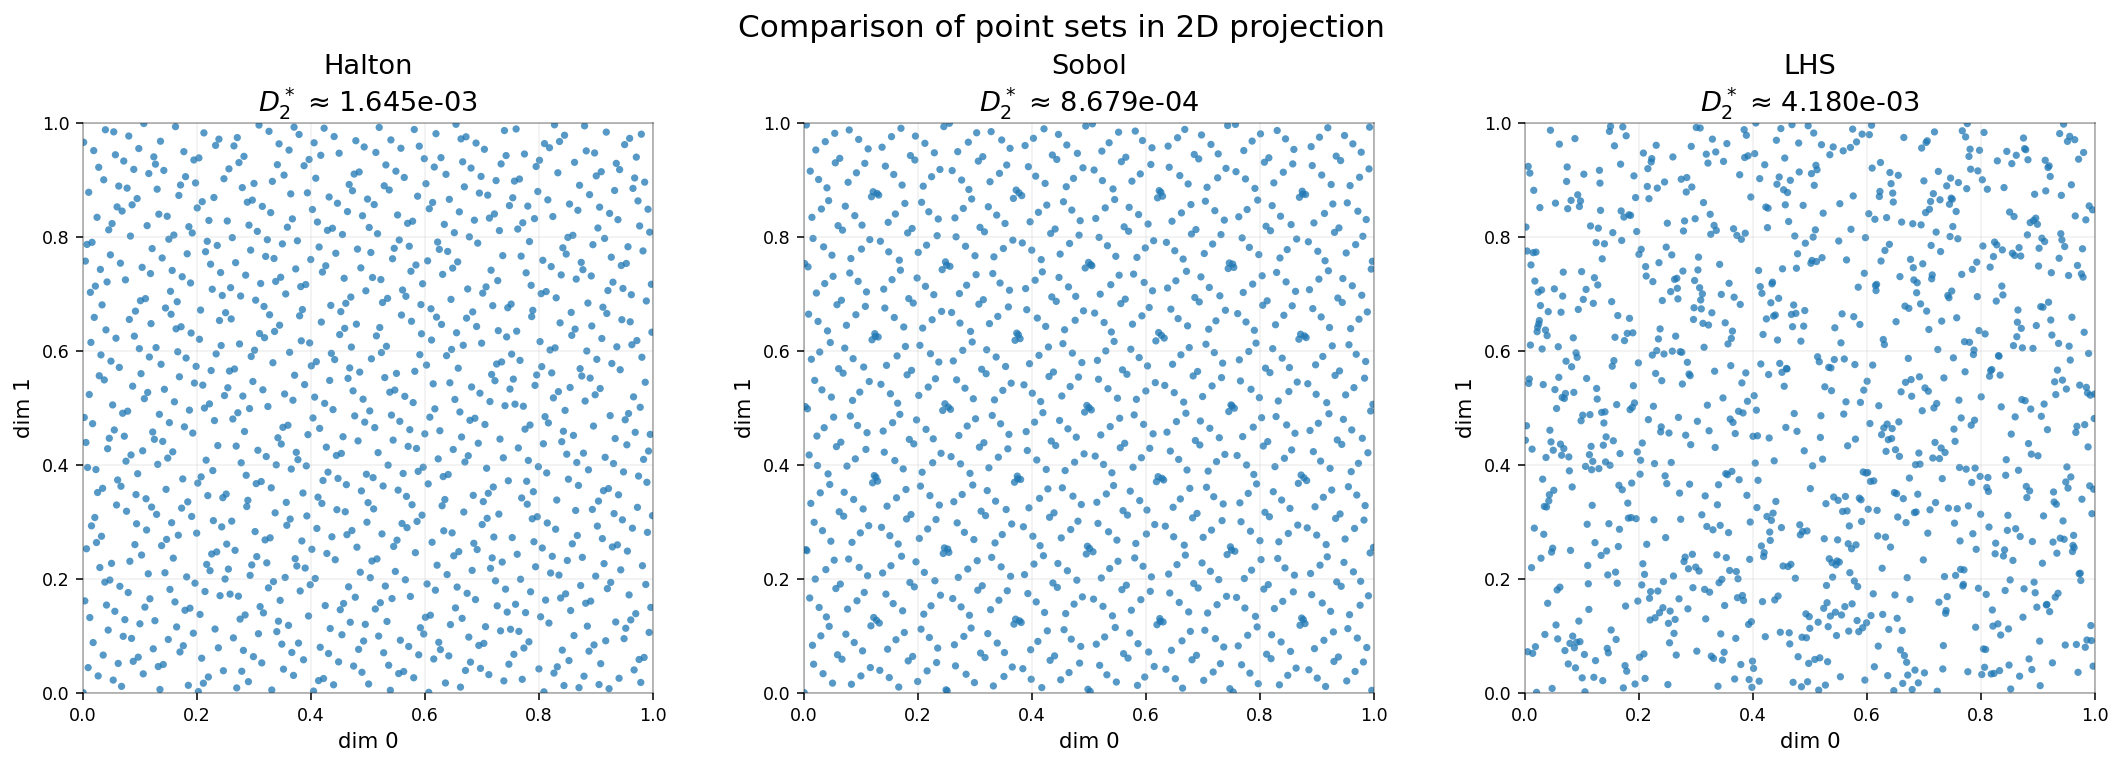

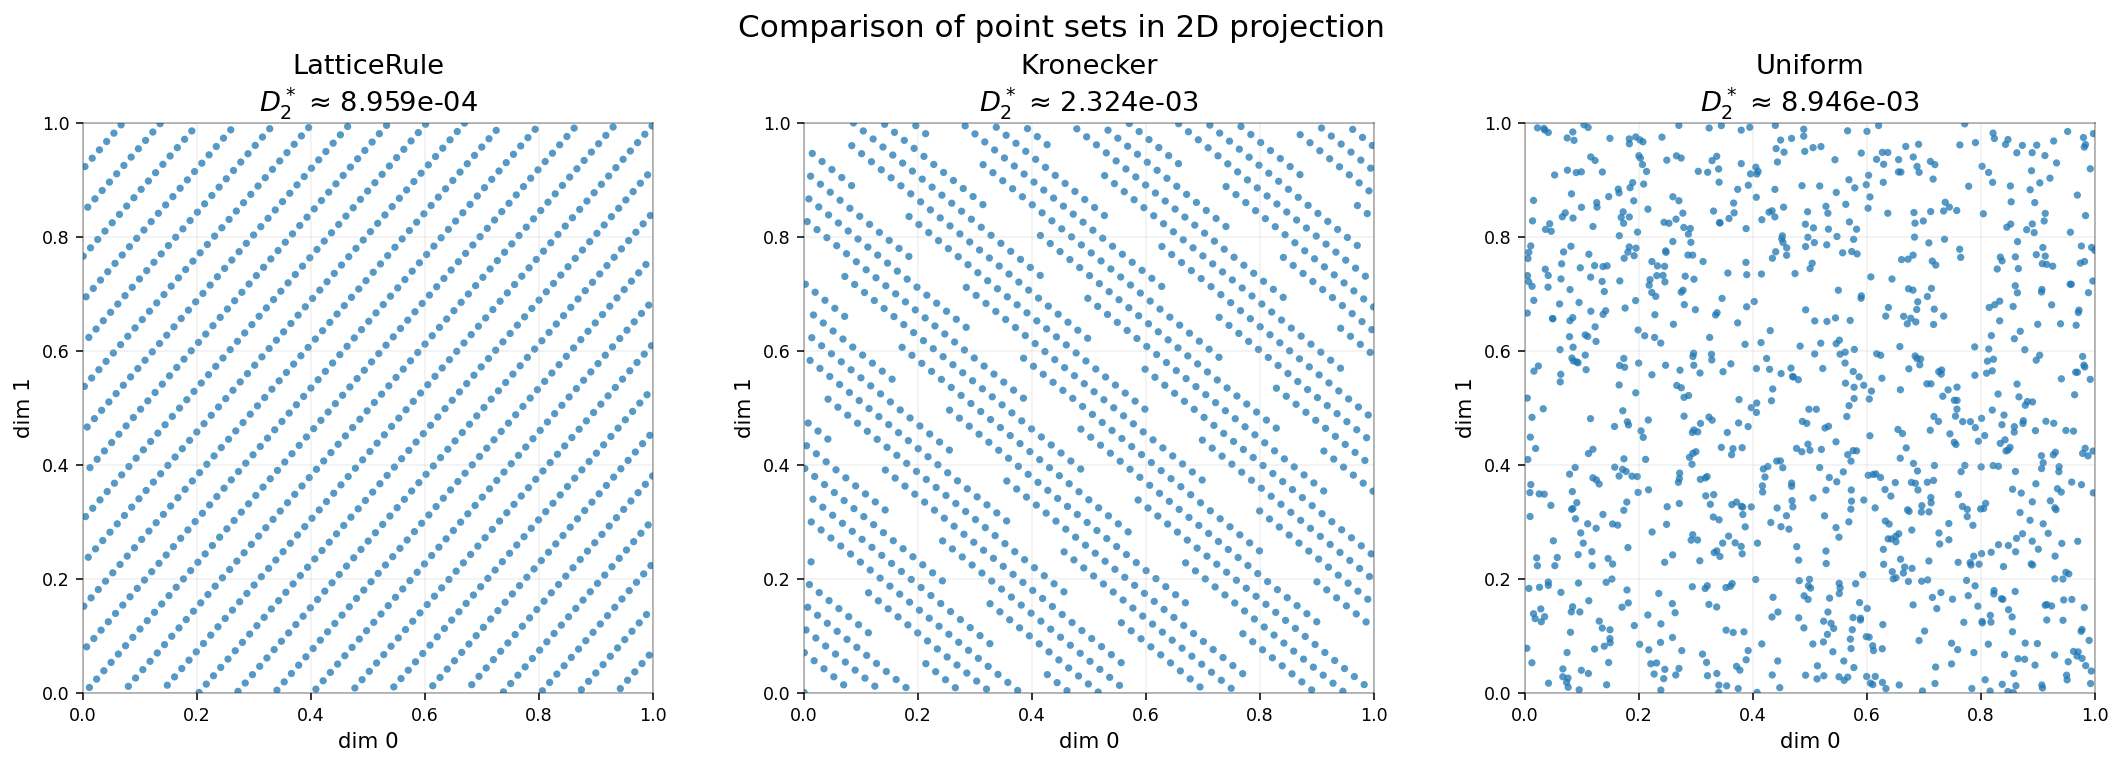

In [16]:
import numpy as np
from scipy.stats import norm

from qmc_lib.sampling.Halton import HaltonSampler
from qmc_lib.sampling.Kronecker import KroneckerSampler
from qmc_lib.sampling.LatinHypercube import LatinHypercubeSampler
from qmc_lib.sampling.LatticeRule import LatticeSampler
from qmc_lib.sampling.Sobol import SobolSampler
from qmc_lib.sampling.UniformSampler import UniformSampler

from qmc_lib.integration.Statistics import Statistics
from qmc_lib.visualization import Visualization



# ============================================================
# Generation of 2D point sets
# ============================================================

# We first generate point sets in dimension 2 in order to visualize them.
# This makes it easier to compare how the different sampling methods fill [0, 1]^2.

dimension = 2
n_samples = 2**10
seed = 0

samples_dict = {
    "Halton": HaltonSampler(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate(),

    "Sobol": SobolSampler(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate(),

    "Kronecker": KroneckerSampler(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate(),

    "LHS": LatinHypercubeSampler(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate(randomized=False),

    "LatticeRule": LatticeSampler(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate(),

    "Uniform": UniformSampler(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate(),
}


# ============================================================
# Visual comparison of point sets
# ============================================================

# We compare the generated point sets in 2D.
# The goal is to visually inspect how each method distributes its points
# over the unit square [0, 1]^2.

Visualization.compare_point_sets_2d(
    samples_dict={
        "Halton": samples_dict["Halton"],
        "Sobol": samples_dict["Sobol"],
        "LHS": samples_dict["LHS"],
    }
)

Visualization.compare_point_sets_2d(
    samples_dict={
        "LatticeRule": samples_dict["LatticeRule"],
        "Kronecker": samples_dict["Kronecker"],
        "Uniform": samples_dict["Uniform"],
    }
)

Random methods are Uniform Sampling and LHS (Latin Hypercube Sampling). We can see that the other methods seem to fill the space more uniformly, which can speed up the approximation process in the sense that fewer sample points are needed to obtain a good approximation of the integral.

The $L^2$-discrepancy $D_2^*$ is an indicator of the uniformity of the sample points. The smaller it is, the better the points fill the space.


## Exact value of the integral

Before applying the sampling methods, we can compute the exact value of the integral. This gives us a reliable reference value to compare the numerical estimators.

Recall that

$$
R(\theta)
=
\mathbb E\left[
\left(
y_{\text{model}}(X)-Y
\right)^2
\right],
$$

where

$$
Y
=
y_{\text{true}}(X)+\varepsilon.
$$

Since the noise $\varepsilon$ is centered, independent of $X$, and satisfies

$$
\varepsilon\sim \mathcal N(0,\sigma^2),
$$

we have

$$
R(\theta)
=
\mathbb E\left[
\left(
y_{\text{model}}(X)-y_{\text{true}}(X)
\right)^2
\right]
+
\sigma^2.
$$

For the model

$$
y_{\text{model}}(X)
=
\theta_0+\theta_1X_1+\theta_2X_2+\theta_3X_3,
$$

and the true function

$$
y_{\text{true}}(X)
=
\sin(X_1)+\frac12 X_2^2-0.3X_3,
$$

one obtains the exact expression

$$
R(\theta)
=
\left(\theta_0-\frac12\right)^2
+
\left[
\theta_1^2
-
2\theta_1 e^{-1/2}
+
\frac{1-e^{-2}}{2}
\right]
+
\left[
\theta_2^2+\frac12
\right]
+
(\theta_3+0.3)^2
+
\sigma^2.
$$

In this example, we use

$$
\theta=(0,0.8,0,-0.2)
$$

and

$$
\sigma=0.2.
$$

Therefore, the exact value is approximately

$$
R(\theta)\approx 0.9018833028414803.
$$

We will now use the sampling methods provided by the library to approximate this integral over the unit cube $[0,1]^4$, and compare the numerical estimates with this exact value.

In [14]:
theta = np.array([0.0, 0.8, 0.0, -0.2])
sigma = 0.2
dimension = 4
n_samples = 4096
n_randomizations = 32 

def exact_risk(theta, sigma=0.2):
    """
    Exact value of the expected squared loss.

    This formula is specific to the example used in this notebook.
    """
    theta0, theta1, theta2, theta3 = theta

    term0 = (theta0 - 0.5) ** 2

    term1 = (
        theta1**2
        - 2.0 * theta1 * np.exp(-0.5)
        + 0.5 * (1.0 - np.exp(-2.0))
    )

    term2 = theta2**2 + 0.5

    term3 = (theta3 + 0.3) ** 2

    noise_term = sigma**2

    return term0 + term1 + term2 + term3 + noise_term


exact_value = exact_risk(theta, sigma)

print(f"Exact value: {exact_value:.15f}")

Exact value: 0.901883302841480


In [20]:
def unit_to_normal(u, eps=1e-12):
    """
    Transform a point from the unit cube to standard normal variables
    using the inverse CDF of the standard normal distribution.
    """
    u = np.clip(u, eps, 1.0 - eps)
    return norm.ppf(u)


def true_function(x):
    """
    True regression function.

    Parameters
    ----------
    x : ndarray
        One point of shape (3,).

    Returns
    -------
    float
        Value of the true function.
    """
    return np.sin(x[0]) + 0.5 * x[1] ** 2 - 0.3 * x[2]


def model_function(x, theta):
    """
    Linear regression model.

    Parameters
    ----------
    x : ndarray
        One point of shape (3,).

    theta : ndarray
        Parameter vector of shape (4,).

    Returns
    -------
    float
        Model prediction.
    """
    return (
        theta[0]
        + theta[1] * x[0]
        + theta[2] * x[1]
        + theta[3] * x[2]
    )

def f(u):
    """
    Integrand defined on the unit cube [0,1]^4.

    This function must take one point u of shape (4,) and return a scalar,
    because the Statistics class vectorizes it internally.

    The first three coordinates are transformed into the Gaussian input X.
    The fourth coordinate is transformed into the Gaussian noise.
    """
    theta = np.array([0.0, 0.8, 0.0, -0.2])
    sigma = 0.2

    z = unit_to_normal(u, eps=1e-12)

    x = z[:3]
    noise = sigma * z[3]

    y_pred = model_function(x, theta)
    y_obs = true_function(x) + noise

    return (y_pred - y_obs) ** 2

def print_statistics(name: str, stats: dict, exact_value: float | None = None) -> None:
    """
    Pretty-print the statistics returned by the Statistics class.

    Important quantities
    --------------------
    estimate:
        Approximation of the integral.

    variance:
        For standard Monte Carlo and LHS, this is the empirical variance
        of f(U).

        For randomized QMC methods, this is the variance between independent
        randomized estimates.

    std:
        Standard deviation associated with the estimated variance.

    standard_error:
        Estimated uncertainty on the final estimator.

    confidence_interval:
        Approximate confidence interval for the integral, when available.

    n_samples:
        Number of points used in each integration run.
    """
    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    print(f"Estimate:          {stats['estimate']:.12e}")
    print(f"Variance:          {stats['variance']:.12e}")
    print(f"Std:               {stats['std']:.12e}")
    print(f"Standard error:    {stats['standard_error']:.12e}")
    print(f"n_samples:         {stats['n_samples']}")

    if stats.get("confidence_level") is not None:
        print(f"Confidence level:  {stats['confidence_level']}")

    if stats.get("confidence_interval") is not None:
        low, high = stats["confidence_interval"]
        print(f"Confidence interval: [{low:.12e}, {high:.12e}]")
    else:
        print("Confidence interval: not returned")

    if exact_value is not None:
        absolute_error = abs(stats["estimate"] - exact_value)
        print(f"Exact value:       {exact_value:.12e}")
        print(f"Absolute error:    {absolute_error:.12e}")
sampling_methods = [
    "Uniform",
    "LHS",
    "Halton",
    "Sobol",
    "Lattice",
    "Kronecker",
]
dimension = 4
n_samples = 4096
seed = 0
confidence_level = 0.95
n_replications = 50

all_stats = {}

for method in sampling_methods:
    statistics = Statistics()

    stats = statistics.compute_statistics(
        f=f,
        sampling_method=method,
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
        confidence_level=confidence_level,
        n_replications=n_replications,
    )

    all_stats[method] = stats

    print_statistics(
        name=method,
        stats=stats,
        exact_value=exact_value,
    )

import pandas as pd

summary = []

for method, stats in all_stats.items():
    summary.append(
        {
            "method": method,
            "estimate": stats["estimate"],
            "absolute_error": abs(stats["estimate"] - exact_value),
            "variance": stats["variance"],
            "std": stats["std"],
            "standard_error": stats["standard_error"],
            "confidence_level": stats["confidence_level"],
            "confidence_interval": stats["confidence_interval"],
            "n_samples": stats["n_samples"],
        }
    )

df_results = pd.DataFrame(summary)
df_results = df_results.sort_values("absolute_error")

df_results



Uniform
Estimate:          9.238553447415e-01
Variance:          7.634592712823e+00
Std:               2.763076675162e+00
Standard error:    4.317307304940e-02
n_samples:         4096
Confidence level:  0.95
Confidence interval: [8.392376764627e-01, 1.008473013020e+00]
Exact value:       9.018833028415e-01
Absolute error:    2.197204190001e-02

LHS
Estimate:          8.995848405665e-01
Variance:          6.395086973456e+00
Std:               2.528850919579e+00
Standard error:    3.951329561842e-02
n_samples:         4096
Confidence level:  0.95
Confidence interval: [8.221402042440e-01, 9.770294768891e-01]
Exact value:       9.018833028415e-01
Absolute error:    2.298462274932e-03

Halton
Estimate:          9.101369629591e-01
Variance:          8.593790785744e-04
Std:               2.931516806321e-02
Standard error:    4.145790825824e-03
n_samples:         4096
Confidence interval: not returned
Exact value:       9.018833028415e-01
Absolute error:    8.253660117649e-03

Sobol
Estimate:

,method,estimate,absolute_error,variance,std,standard_error,confidence_level,confidence_interval,n_samples
4,Lattice,0.901749,0.000134,0.000041,0.006398,0.000905,NaN,None,4096
3,Sobol,0.902070,0.000187,0.000033,0.005753,0.000814,NaN,None,4096
5,Kronecker,0.899796,0.002087,0.000053,0.007280,0.001030,NaN,None,4096
1,LHS,0.899585,0.002298,6.395087,2.528851,0.039513,0.95,"(0.8221402042439543, 0.9770294768891419)",4096
2,Halton,0.910137,0.008254,0.000859,0.029315,0.004146,NaN,None,4096
0,Uniform,0.923855,0.021972,7.634593,2.763077,0.043173,0.95,"(0.8392376764627385, 1.0084730130202324)",4096


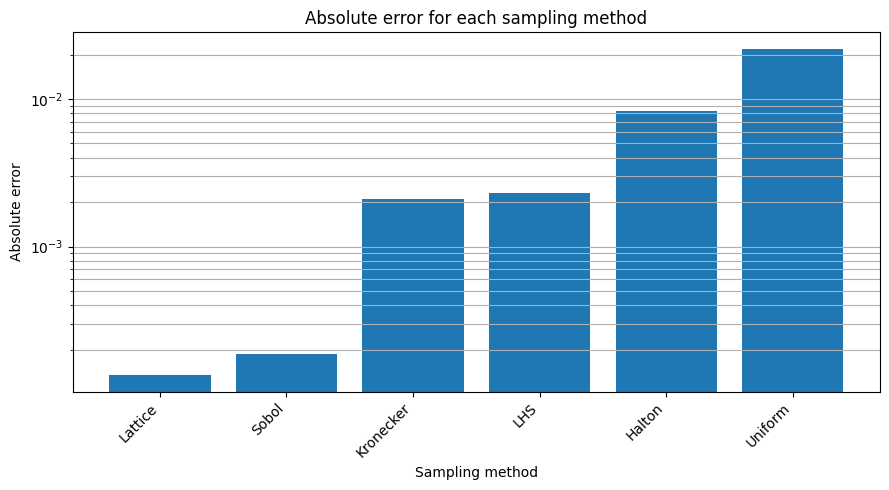

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))

plt.bar(
    df_results["method"],
    df_results["absolute_error"],
)

plt.yscale("log")
plt.xlabel("Sampling method")
plt.ylabel("Absolute error")
plt.title("Absolute error for each sampling method")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", which="both")

plt.tight_layout()
plt.show()

### Conclusion

This example shows how the library can be used on a practical integration problem motivated by regression and expected loss estimation.

After transforming the original Gaussian expectation into an integral over the unit cube $[0,1]^4$, we were able to apply several sampling methods from the library. The numerical results show that the estimators provide accurate approximations of the exact value, and that quasi-Monte Carlo methods based on low-discrepancy sequences generally achieve better accuracy than standard random sampling for the same number of points.

This illustrates the main advantage of QMC methods: by filling the integration domain more evenly, they can reduce the approximation error and make numerical integration more efficient.